# 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
# 2. Load dataset

In [2]:
production = pd.read_sas('../data/01_raw/production.sas7bdat', encoding='utf-8')
default = pd.read_sas('../data/01_raw/default.sas7bdat', encoding='utf-8')
transaction = pd.read_sas('../data/01_raw/transactions.sas7bdat', encoding='utf-8')

print(f"Production dataset shape: {production.shape}")
print(f"Default dataset shape: {default.shape}")
print(f"Transaction dataset shape: {transaction.shape}")

display(production.head(3))
display(default.head(3))
display(transaction.head(3))

common_cols = ['aid', 'cid', 'product', 'period']
abt_raw = pd.merge(production, default, how='inner', on=common_cols)

print(f"ABT dataset shape: {abt_raw.shape}")
display(abt_raw.head(3))

Production dataset shape: (68644, 20)
Default dataset shape: (68644, 8)
Transaction dataset shape: (1175025, 14)


,cid,aid,product,period,act_age,act_cc,act_loaninc,app_income,app_loan_amount,app_n_installments,app_number_of_children,app_spendings,app_installment,app_char_branch,app_char_gender,app_char_job_code,app_char_marital_status,app_char_city,app_char_home_status,app_char_cars
0,0000000001,ins1970010100011,ins,197001,59.0,0.651685,3.130435,2047.0,6408.0,12.0,0.0,800.0,534.0,DiY,Female,Retired,Maried,Large,Owner,Owner
1,0000000001,ins1970010100012,ins,197001,59.0,0.477772,1.043478,2047.0,2136.0,12.0,0.0,800.0,178.0,Fenitures,Female,Retired,Maried,Large,Owner,Owner
2,0000000002,ins1970010100021,ins,197001,52.0,0.514265,0.716634,4136.0,2964.0,12.0,1.0,1880.0,247.0,Fenitures,Female,Owner company,Maried,Large,Owner,Owner


,cid,aid,product,period,default3,default6,default9,default12
0,0000000001,css1970020500001,css,197002,0.0,0.0,0.0,0.0
1,0000000060,css1970020700004,css,197002,0.0,0.0,0.0,0.0
2,0000000013,css1970021100003,css,197002,0.0,0.0,0.0,0.0


,cid,aid,product,period,fin_period,status,due_installments,paid_installments,pay_days,income,n_installments,spendings,installment,leftn_installments
0,0000000001,ins1970010100011,ins,197001,197001,A,0.0,0.0,0.0,2047.0,12.0,800.0,534.0,12.0
1,0000000001,ins1970010100011,ins,197002,197001,A,0.0,1.0,-1.0,2047.0,12.0,800.0,534.0,11.0
2,0000000001,ins1970010100011,ins,197003,197001,A,0.0,2.0,-6.0,2047.0,12.0,800.0,534.0,10.0


ABT dataset shape: (68644, 24)


,cid,aid,product,period,act_age,act_cc,act_loaninc,app_income,app_loan_amount,app_n_installments,...,app_char_gender,app_char_job_code,app_char_marital_status,app_char_city,app_char_home_status,app_char_cars,default3,default6,default9,default12
0,0000000001,ins1970010100011,ins,197001,59.0,0.651685,3.130435,2047.0,6408.0,12.0,...,Female,Retired,Maried,Large,Owner,Owner,0.0,0.0,0.0,NaN
1,0000000001,ins1970010100012,ins,197001,59.0,0.477772,1.043478,2047.0,2136.0,12.0,...,Female,Retired,Maried,Large,Owner,Owner,0.0,0.0,NaN,1.0
2,0000000002,ins1970010100021,ins,197001,52.0,0.514265,0.716634,4136.0,2964.0,12.0,...,Female,Owner company,Maried,Large,Owner,Owner,0.0,0.0,0.0,0.0


In [6]:
production.info()

<class 'pandas.DataFrame'>
RangeIndex: 68644 entries, 0 to 68643
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cid                      68644 non-null  str    
 1   aid                      68644 non-null  str    
 2   product                  68644 non-null  str    
 3   period                   68644 non-null  str    
 4   act_age                  68644 non-null  float64
 5   act_cc                   68644 non-null  float64
 6   act_loaninc              68644 non-null  float64
 7   app_income               68644 non-null  float64
 8   app_loan_amount          68644 non-null  float64
 9   app_n_installments       68644 non-null  float64
 10  app_number_of_children   68644 non-null  float64
 11  app_spendings            68644 non-null  float64
 12  app_installment          68644 non-null  float64
 13  app_char_branch          68644 non-null  str    
 14  app_char_gender          68644 no

In [7]:
default.info()

<class 'pandas.DataFrame'>
RangeIndex: 68644 entries, 0 to 68643
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cid        68644 non-null  str    
 1   aid        68644 non-null  str    
 2   product    68644 non-null  str    
 3   period     68644 non-null  str    
 4   default3   58542 non-null  float64
 5   default6   58881 non-null  float64
 6   default9   61312 non-null  float64
 7   default12  62184 non-null  float64
dtypes: float64(4), str(4)
memory usage: 4.2 MB


In [8]:
transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175025 entries, 0 to 1175024
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   cid                 1175025 non-null  str    
 1   aid                 1175025 non-null  str    
 2   product             1175025 non-null  str    
 3   period              1175025 non-null  str    
 4   fin_period          1175025 non-null  str    
 5   status              1175025 non-null  str    
 6   due_installments    1175025 non-null  float64
 7   paid_installments   1175025 non-null  float64
 8   pay_days            846655 non-null   float64
 9   income              1175025 non-null  float64
 10  n_installments      1175025 non-null  float64
 11  spendings           1175025 non-null  float64
 12  installment         1175025 non-null  float64
 13  leftn_installments  1175025 non-null  float64
dtypes: float64(8), str(6)
memory usage: 125.5 MB


All the data has been processed carefully and are in the correct dtype expected

In [9]:
num_prd = production.select_dtypes(include=['number']).columns
num_prd_df = production[num_prd]

num_prd_desc = num_prd_df.describe()
prd_skew = pd.DataFrame(num_prd_df.skew()).T.rename(index={0: 'Skewness'})
prd_kurt = pd.DataFrame(num_prd_df.kurt()).T.rename(index={0: 'Kurtosis'})

# Calculate the actual share of missing values only on the numeric features
missing_share = pd.DataFrame(num_prd_df.isnull().mean()).T.rename(index={0: 'Missing share'})

num_prd_desc = pd.concat([num_prd_desc, prd_skew, prd_kurt, missing_share], axis=0)

display(num_prd_desc)

,act_age,act_cc,act_loaninc,app_income,app_loan_amount,app_n_installments,app_number_of_children,app_spendings,app_installment
count,68644.000000,68644.000000,68644.000000,68644.000000,68644.000000,68644.000000,68644.000000,68644.000000,68644.000000
mean,59.701489,0.571233,4.261989,1930.513796,4911.989977,21.819533,0.584669,689.669308,226.695836
std,11.243248,0.234497,4.174917,1562.828894,2503.437455,7.028248,0.805909,634.773321,88.377739
min,17.000000,0.029862,0.077085,300.000000,720.000000,12.000000,0.000000,0.000000,60.000000
25%,52.000000,0.415266,1.718622,881.000000,3768.000000,12.000000,0.000000,300.000000,208.000000
50%,59.000000,0.552553,2.972751,1575.000000,5000.000000,24.000000,0.000000,520.000000,208.000000
75%,67.000000,0.691622,5.378622,2372.000000,5000.000000,24.000000,1.000000,840.000000,222.000000
max,93.000000,2.609914,67.013850,16371.000000,30276.000000,36.000000,3.000000,8580.000000,971.000000
Skewness,0.062796,1.049064,3.290834,2.335480,2.382114,0.056159,1.116099,3.168525,1.875972
Kurtosis,-0.228656,3.243705,19.930024,7.957414,10.459281,-0.321183,0.147707,16.212411,5.362535


---
# 3. Data Exploratory

## 3.1 Volume, Coverage

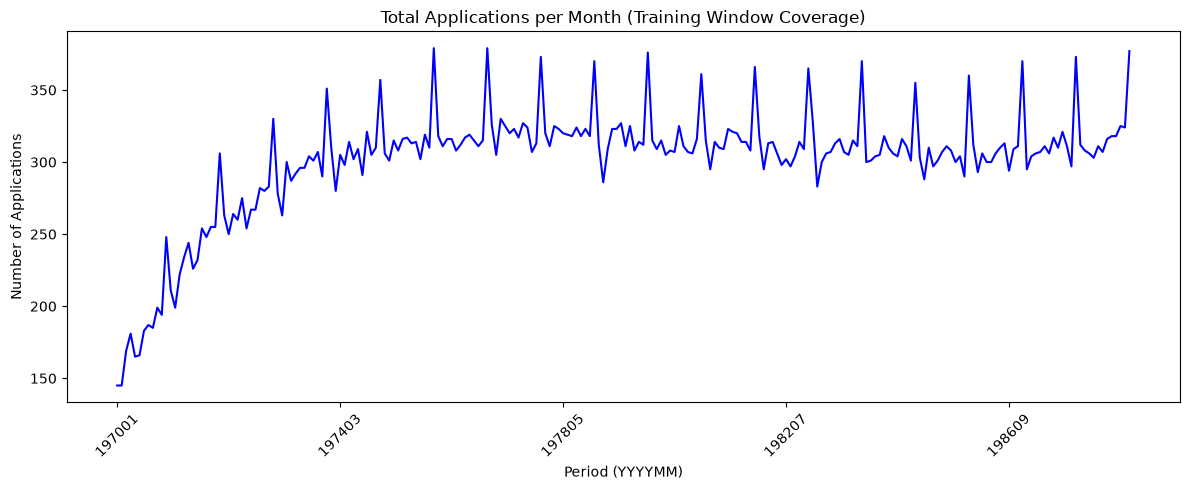

In [10]:
# How many applications per month?
plt.figure(figsize=(12, 5))
app_counts = production.groupby('period')['aid'].count()
app_counts.plot(kind='line', color='b')
plt.title("Total Applications per Month (Training Window Coverage)")
plt.ylabel("Number of Applications")
plt.xlabel("Period (YYYYMM)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In the first 5 years, the number of applications are small and gradually increased to keep the level 300-350 applications per period

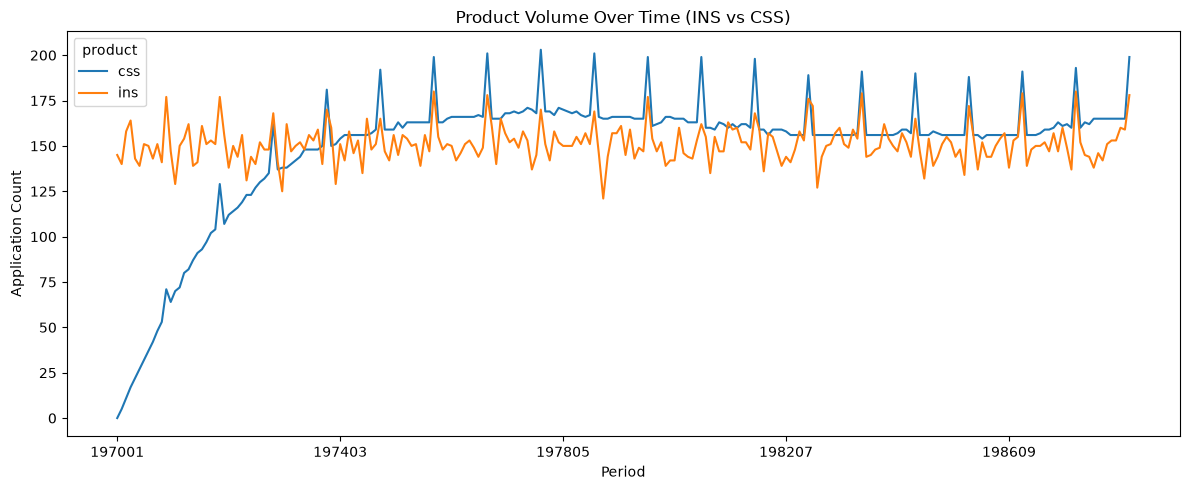

In [11]:
# Product split (ins vs css) over time
prod_time = pd.crosstab(production['period'], production['product'])
prod_time.plot(kind='line', figsize=(12, 5))
plt.title("Product Volume Over Time (INS vs CSS)")
plt.ylabel("Application Count")
plt.xlabel("Period")
plt.tight_layout()
plt.show()

Very few `css` applications before 1740

--- Summary of Loans per Customer ---
count    24577.000000
mean         2.793018
std          6.222891
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         68.000000
Name: aid, dtype: float64


/var/folders/w7/g4w1_48n7hq28j0995d9c_cr0000gn/T/ipykernel_57761/3112252446.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=loans_per_cust.values, palette="viridis")


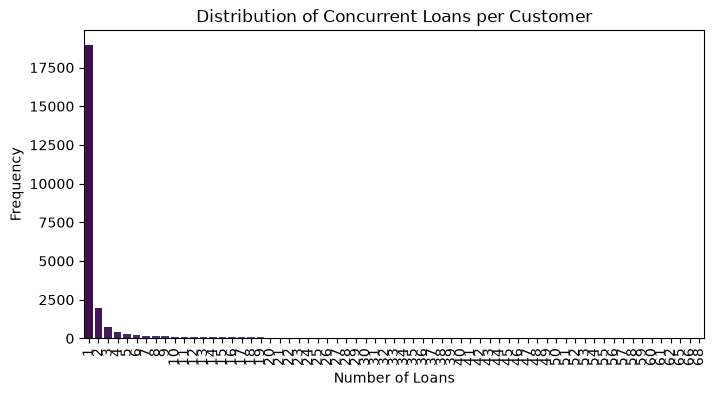

In [12]:
# Loans per customer
loans_per_cust = production.groupby('cid')['aid'].nunique()
print("--- Summary of Loans per Customer ---")
print(loans_per_cust.describe())

plt.figure(figsize=(8, 4))
sns.countplot(x=loans_per_cust.values, palette="viridis")
plt.title("Distribution of Concurrent Loans per Customer")
plt.xlabel("Number of Loans")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

Most of the customers have only 1 loan $\Rightarrow$ Loan-level adequate

In [13]:
# Cross-table integrity checks
prod_aids = set(production['aid'])
trans_aids = set(transaction['aid'])
def_aids = set(default['aid'])

print("\n--- Cross-Table Integrity ---")
print(f"Total Unique AIDs in Production: {len(prod_aids)}")
print(f"Total Unique AIDs in Defaults: {len(def_aids)}")
print(f"Total Unique AIDs in Transactions: {len(trans_aids)}")
print(f"Defaults missing in Production (Leakage/Error): {len(def_aids - prod_aids)}")
print(f"Defaults missing in Transactions (No History): {len(def_aids - trans_aids)}")


--- Cross-Table Integrity ---
Total Unique AIDs in Production: 68644
Total Unique AIDs in Defaults: 68644
Total Unique AIDs in Transactions: 68644
Defaults missing in Production (Leakage/Error): 0
Defaults missing in Transactions (No History): 0


## 3.2 The Target signal analysis

In [14]:
# Distribution of default flag values BEFORE cleaning
print("--- Raw Default12 Flag Distribution ---")
print(default['default12'].value_counts(dropna=False))

# Clean the target flags: Drop indeterminate ('.i', '.d') rows for modeling
df_clean = default[~default['default12'].isin(['.i', '.d'])].copy()
df_clean['default12'] = pd.to_numeric(df_clean['default12'])

df_clean_3 = default[~default['default3'].isin(['.i', '.d'])].copy()
df_clean_3['default3'] = pd.to_numeric(df_clean_3['default3'])

--- Raw Default12 Flag Distribution ---
default12
0.0    37508
1.0    24676
NaN     6460
Name: count, dtype: int64


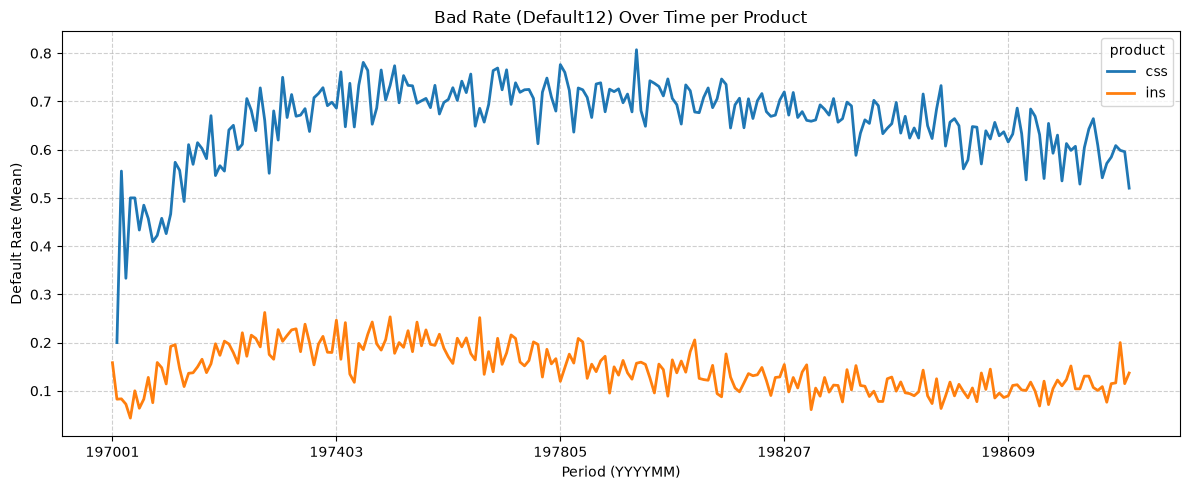

In [15]:
# Overall default12 rate, per product, over time
# Merge to get product info alongside the clean default flag
def_prod = df_clean.merge(
    production[['aid', 'product', 'period']], 
    on=['aid', 'product', 'period'], 
    how='inner'
)

# Calculate the mean default rate grouped by period and product
def_rate_time = def_prod.groupby(['period', 'product'])['default12'].mean().unstack()

# Plot the trends
def_rate_time.plot(figsize=(12, 5), linewidth=2)
plt.title("Bad Rate (Default12) Over Time per Product")
plt.ylabel("Default Rate (Mean)")
plt.xlabel("Period (YYYYMM)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Default rate of `css` 5x higher than `ins` $\Rightarrow$ Need seperate models

In [16]:
# Joint distribution default3 -> default12
joint_df = default[~default['default3'].isin(['.i', '.d']) & ~default['default12'].isin(['.i', '.d'])].copy()
joint_df['default3'] = pd.to_numeric(joint_df['default3'])
joint_df['default12'] = pd.to_numeric(joint_df['default12'])

print("\n--- Transition Matrix: Default3 -> Default12 (Row Normalized) ---")
print(pd.crosstab(joint_df['default3'], joint_df['default12'], normalize='index').round(4))


--- Transition Matrix: Default3 -> Default12 (Row Normalized) ---
default12     0.0     1.0
default3                 
0.0        0.8828  0.1172
1.0        0.0000  1.0000


Customers who are `default3` 100% default in 12 months.
Customers who are not `default3` is 11.72% default in 12 months.

## 3.3 Fine-Grained Transaction & Behavioral Diagnostics

--- Transaction History for AID: ins1970031300011 ---


,period,fin_period,status,pay_days,due_installments,leftn_installments
7032,197003,197003,A,0.0,0.0,36.0
7033,197004,197003,A,-2.0,0.0,35.0
7034,197005,197003,A,-2.0,0.0,34.0
7035,197006,197003,A,-3.0,0.0,33.0
7036,197007,197003,A,-5.0,0.0,32.0
7037,197008,197003,A,-1.0,0.0,31.0
7038,197009,197003,A,-5.0,0.0,30.0
7039,197010,197003,A,-2.0,0.0,29.0
7040,197011,197003,A,-0.0,0.0,28.0
7041,197012,197003,A,-0.0,0.0,27.0


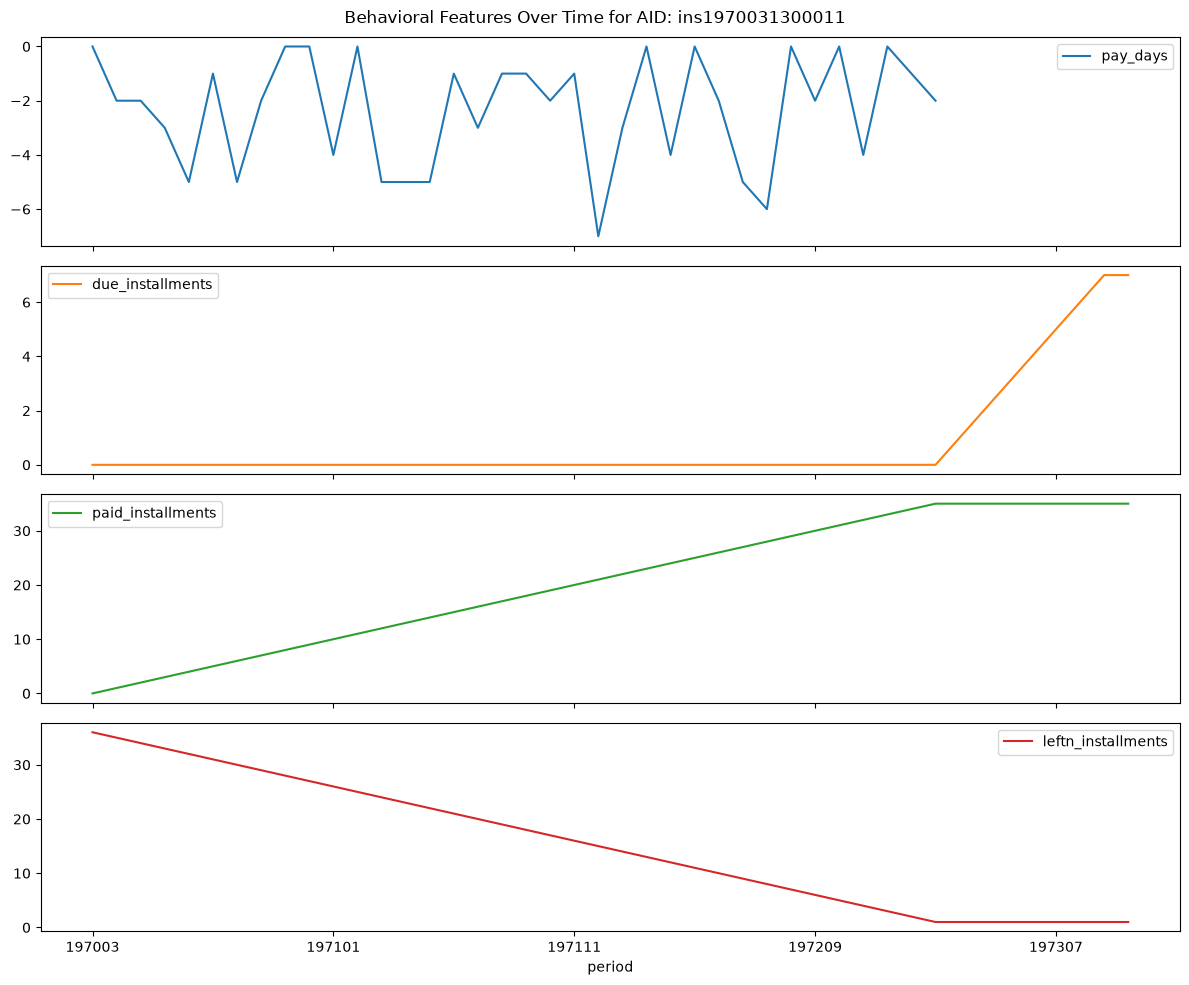

In [17]:
# Deep dive into a single active AID's history
sample_aid = transaction['aid'].value_counts().index[0] # Pick the AID with the most history
sample_df = transaction[transaction['aid'] == sample_aid].sort_values('period')

print(f"--- Transaction History for AID: {sample_aid} ---")
display(sample_df[['period', 'fin_period', 'status', 'pay_days', 'due_installments', 'leftn_installments']].head(10))

sample_df.set_index('period')[['pay_days', 'due_installments', 'paid_installments', 'leftn_installments']].plot(
    subplots=True, figsize=(12, 10), title=f"Behavioral Features Over Time for AID: {sample_aid}"
)
plt.tight_layout()
plt.show()

`period` is the reporting month, `fin_period` is the first month the customer start the application.

In [18]:
# Distribution of Status
print("--- Transaction Status Distribution ---")
print(transaction['status'].value_counts(normalize=True).round(4) * 100)

--- Transaction Status Distribution ---
status
A    94.63
B     2.72
C     2.65
Name: proportion, dtype: float64


In [19]:
# Customer holding both products simultaneously
cross_prod = production.groupby('cid')['product'].nunique()
multi_product_cids = cross_prod[cross_prod > 1].index

if len(multi_product_cids) > 0:
    sample_multi_cid = multi_product_cids[0]
    print(f"\n--- Customer {sample_multi_cid} holding multiple products ---")
    display(production[production['cid'] == sample_multi_cid][['cid', 'aid', 'product', 'period']])


--- Customer 0000000001 holding multiple products ---


,cid,aid,product,period
0,0000000001,ins1970010100011,ins,197001
1,0000000001,ins1970010100012,ins,197001
5,0000000001,ins1970010100042,ins,197001
7,0000000001,ins1970010200013,ins,197001
9,0000000001,ins1970010200022,ins,197001
13,0000000001,ins1970010300022,ins,197001
21,0000000001,ins1970010500022,ins,197001
35,0000000001,ins1970010800023,ins,197001
51,0000000001,ins1970011100023,ins,197001
56,0000000001,ins1970011200033,ins,197001


For customer with multiple loan, the risk is about the customer, not the loan which motivates the per-customer aggregates

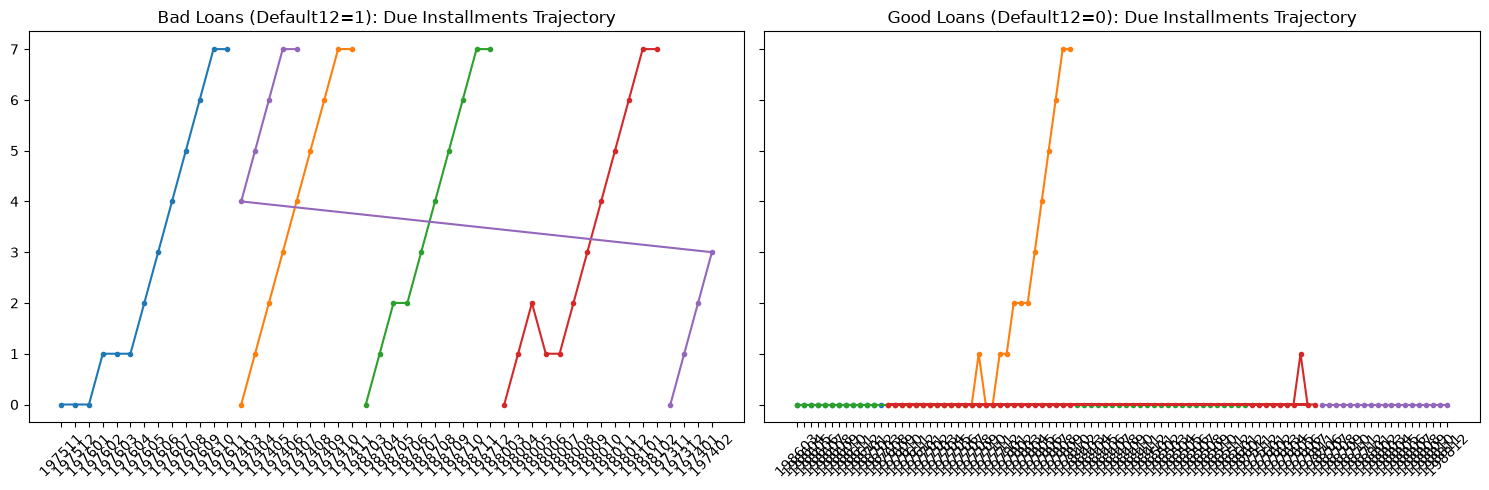

In [20]:
# Compare due_installments trajectory for Good vs Bad loans
bad_loans = df_clean[df_clean['default12'] == 1]['aid'].sample(5, random_state=42).tolist()
good_loans = df_clean[df_clean['default12'] == 0]['aid'].sample(5, random_state=42).tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for loan in bad_loans:
    df_l = transaction[transaction['aid'] == loan].sort_values('period')
    axes[0].plot(df_l['period'], df_l['due_installments'], marker='.', label=loan)
axes[0].set_title("Bad Loans (Default12=1): Due Installments Trajectory")
axes[0].tick_params(axis='x', rotation=45)

for loan in good_loans:
    df_l = transaction[transaction['aid'] == loan].sort_values('period')
    axes[1].plot(df_l['period'], df_l['due_installments'], marker='.', label=loan)
axes[1].set_title("Good Loans (Default12=0): Due Installments Trajectory")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3.4 Distributions, Outliers & Missing Values

--- Skewness of Numeric Features ---
act_loaninc               3.290834
app_spendings             3.168525
app_loan_amount           2.382114
app_income                2.335480
app_installment           1.875972
app_number_of_children    1.116099
act_cc                    1.049064
act_age                   0.062796
app_n_installments        0.056159
dtype: float64


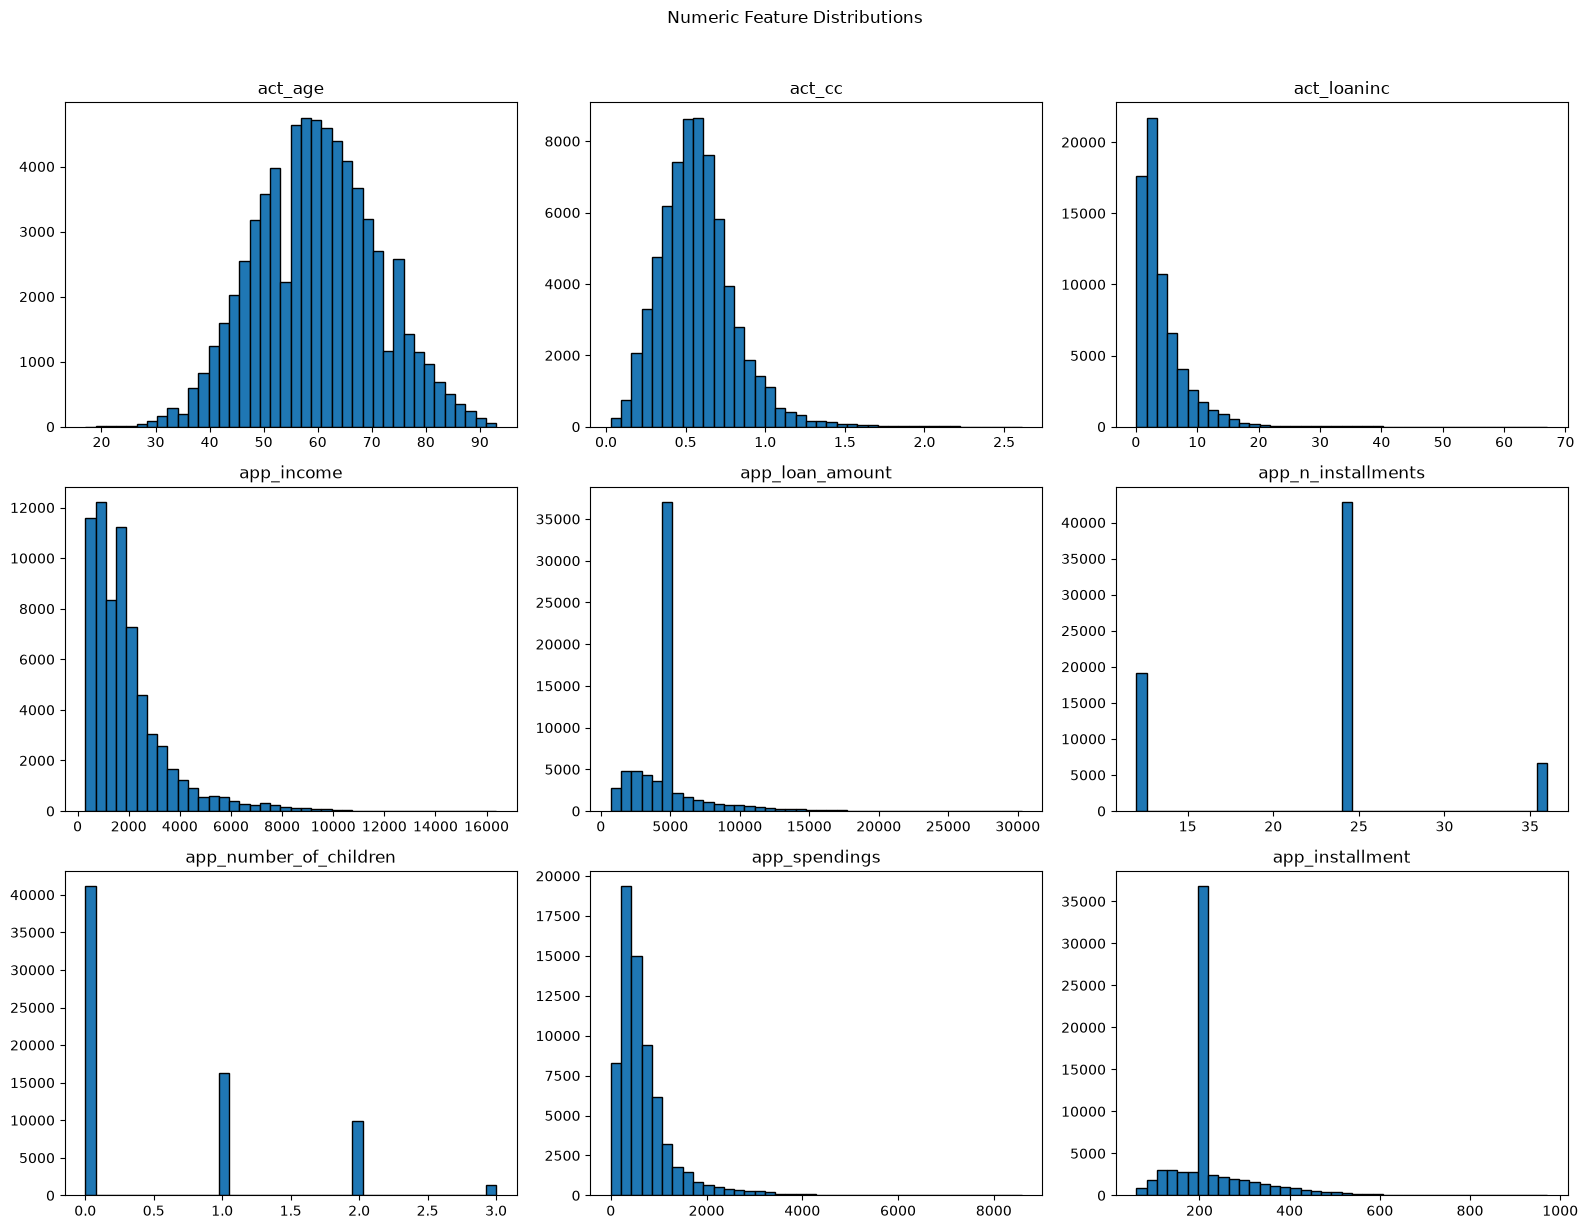

In [21]:
# Histograms of Numeric Features
num_cols = production.select_dtypes(include=['float64']).columns
print("--- Skewness of Numeric Features ---")
print(production[num_cols].skew().sort_values(ascending=False))

production[num_cols].hist(bins=40, figsize=(16, 12), edgecolor='black', grid=False)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

Skewnesss is mild and acceptable with all <= 3.

In [22]:
# Missing-value share per column
print("\n--- Missing Value Percentages ---")
print("Production Table:\n", (production.isnull().mean() * 100).round(2)[production.isnull().mean() > 0])
print("\nTransactions Table:\n", (transaction.isnull().mean() * 100).round(2)[transaction.isnull().mean() > 0])


--- Missing Value Percentages ---
Production Table:
 Series([], dtype: float64)

Transactions Table:
 pay_days    27.95
dtype: float64


In [23]:
# Frequency and Bad Rate per Category (Pre-binning analysis)
prod_with_target = production.merge(df_clean[['aid', 'default12']], on='aid', how='inner')
char_cols = [c for c in production.columns if c.startswith('app_char_')]

for col in char_cols:
    agg = prod_with_target.groupby(col)['default12'].agg(['count', 'mean']).rename(columns={'count': 'Volume', 'mean': 'Bad Rate'})
    agg['Volume %'] = (agg['Volume'] / agg['Volume'].sum() * 100).round(2)
    agg['Bad Rate'] = (agg['Bad Rate'] * 100).round(2)
    display(agg.sort_values('Volume', ascending=False))

,Volume,Bad Rate,Volume %
app_char_branch,,,
Empty,29777,67.12,47.89
Radio-TV,10888,14.47,17.51
Fenitures,10794,14.52,17.36
DiY,5792,14.45,9.31
Computers,4933,14.41,7.93


,Volume,Bad Rate,Volume %
app_char_gender,,,
Female,39875,43.00,64.12
Male,22309,33.75,35.88


,Volume,Bad Rate,Volume %
app_char_job_code,,,
Retired,35492,42.30,57.08
Permanent,17919,32.38,28.82
Owner company,5451,35.06,8.77
Contract,3322,58.67,5.34


,Volume,Bad Rate,Volume %
app_char_marital_status,,,
Maried,34222,36.27,55.03
Divorced,15007,43.16,24.13
Widowed,11663,43.63,18.76
Singiel,1292,53.95,2.08


,Volume,Bad Rate,Volume %
app_char_city,,,
Big,21199,39.30,34.09
Medium,20800,40.28,33.45
Small,10382,39.93,16.70
Large,9803,38.96,15.76


,Volume,Bad Rate,Volume %
app_char_home_status,,,
Owner,55046,40.28,88.52
Rental,7130,34.98,11.47
With parents,8,87.50,0.01


,Volume,Bad Rate,Volume %
app_char_cars,,,
Owner,51836,41.02,83.36
No,10348,32.98,16.64


Only `app_char_home_status = 'With parents'` has very small number of observation, which can not give reliable WOE.

## 3.5 Feature Relationships, Leakage & Sanity Checks

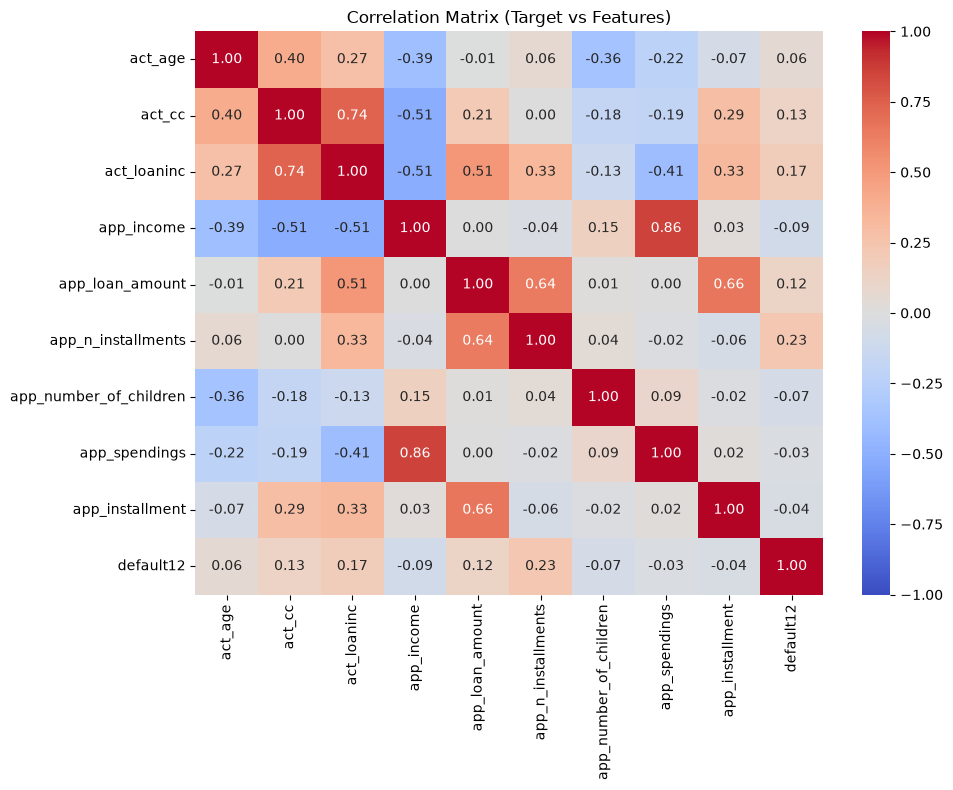

--- Highest Correlations with Target ---
app_n_installments    0.228473
act_loaninc           0.172629
act_cc                0.127736
app_loan_amount       0.121800
app_income            0.091114
Name: default12, dtype: float64


In [24]:
# Compute correlation of every numeric column with default12
act_cols = [c for c in prod_with_target.columns if c.startswith('act_') or c.startswith('app_')] + ['default12']
numeric_act_cols = prod_with_target[act_cols].select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
corr_matrix = numeric_act_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Target vs Features)")
plt.tight_layout()
plt.show()

# Print high correlations with target (potential leakage)
target_corr = corr_matrix['default12'].drop('default12').abs()
print("--- Highest Correlations with Target ---")
print(target_corr.sort_values(ascending=False).head(5))

In [25]:
# Verify act_cc logical relationship
production['calculated_cc'] = (production['app_installment'] + production['app_spendings']) / production['app_income']
production['cc_difference'] = (production['act_cc'] - production['calculated_cc']).abs()

print("\n--- Sanity Check: act_cc vs Calculated CC ---")
print(f"Max Absolute Error: {production['cc_difference'].max():.6f}")
print(f"Mean Absolute Error: {production['cc_difference'].mean():.6f}")
if production['cc_difference'].max() < 0.01:
    print("Verification Passed: act_cc structurally matches the component formula.")
else:
    print("Warning: act_cc diverges significantly from the component formula.")


--- Sanity Check: act_cc vs Calculated CC ---
Max Absolute Error: 0.000000
Mean Absolute Error: 0.000000
Verification Passed: act_cc structurally matches the component formula.


## 3.6 EDA Summary

- We should not model the first 5 years of `css` (?)
- Build 2 separate PD models
- Use WOE binning instead of raw values
- For small nominal categories, merges their bins
- Keeps a "Missing" bin instead of imputing

## 3.7 Conceptual Modeling Design (Synthesis)

### (a) What will one row of `abt_app` represent?
One row in the Analytical Base Table (`abt_app`) represents a **unique application snapshot (`aid`) at its specific observation point (`period`)**. Because a single customer (`cid`) can hold multiple concurrent loans over their lifecycle, the grain of this table must remain at the loan/application level rather than a pure customer level to correctly map application-specific risk characteristics and historical default flags.

### (b) What is the target?
The core modeling target is **`default12`**, a binary classification flag ($0 = \text{Good}$, $1 = \text{Bad}$). It indicates whether a loan performance sequence crossed the defined delinquency threshold within a strict 12-month performance window following the application snapshot.

### (c) If production already has `act_cc` etc., why do we need to derive more behavioral features from transactions?
While variables like `act_cc` provide a highly valuable static snapshot of a customer's total exposure at the exact moment of application, **credit risk is fundamentally behavioral and dynamic**. 

A single snapshot cannot differentiate between a customer who is steadily paying down a stable balance versus a customer who is rapidly accelerating their utilization due to financial distress. 
* **`act_cc`**: Represents a static cross-sectional level at one specific moment.
* **Derived Transactional Features (e.g., `agr12_Max_CMaxA_Due`)**: Capture temporal trends, payment volatility, and velocity over a rolling 12-month historical window. 

Unlocking these underlying transaction behaviors provides the directional signal needed to robustly predict default risks compared to relying on point-in-time constraints alone.